# Supplementary Figure 1: Detailed Performance Data

Complete benchmark results for all 55 original datasets (5 tools)
plus 11 CELLxGENE datasets (CrossCell only).

| Panel | Content |
|---|---|
| **S3A** | Full performance table (55 datasets × 5 tools) |
| **S3B** | Per-dataset time comparison bar chart |
| **S3C** | Speedup distribution by dataset category |

**Data source**: `robustness_benchmark.json`.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import json, os, re, subprocess, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path('/benchmark/results')
DATA_DIR = Path('/benchmark/data/generated')
FIGURES_DIR_MAIN = Path('/benchmark/figures/main')
FIGURES_DIR_SUPP = Path('/benchmark/figures/supplementary')
TMP_DIR = Path('/tmp/notebook_work')

for d in [RESULTS_DIR, FIGURES_DIR_MAIN, FIGURES_DIR_SUPP, TMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 10, 'axes.labelsize': 11,
    'axes.titlesize': 12, 'figure.dpi': 150,
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

COLORS = {
    'CrossCell': '#025e8d', 'Zellkonverter': '#f58220',
    'anndataR': '#00a69d', 'convert2anndata': '#785ba7',
    'easySCF': '#c75301',
    'success': '#00a69d', 'failed': '#be1818', 'na': '#999999',
}

ALL_TOOLS = ['CrossCell', 'Zellkonverter', 'anndataR', 'convert2anndata', 'easySCF']

def extract_error_reason(stderr_text):
    """Extract a short error reason from R/tool stderr output."""
    if not stderr_text:
        return 'unknown error'
    for line in stderr_text.split('\n'):
        line = line.strip()
        if line.startswith('Error') or 'error' in line.lower():
            return line[:120] + ('...' if len(line) > 120 else '')
    lines = [l.strip() for l in stderr_text.strip().split('\n') if l.strip()]
    if lines:
        return lines[-1][:120]
    return 'unknown error'

FIGURES_DIR = FIGURES_DIR_SUPP
FIG3_FILE = RESULTS_DIR / 'robustness_benchmark.json'
print('✅ Environment setup complete')


✅ Environment setup complete


## 1. Load All Performance Data

In [2]:

# Load performance data from robustness_benchmark.json
all_results = {}
if FIG3_FILE.exists():
    with open(FIG3_FILE) as f:
        fig3 = json.load(f)
    print(f'\u2705 Loaded robustness benchmark results')
    all_results['fig3'] = fig3
else:
    print('\u26a0\ufe0f robustness_benchmark.json not found')

# Build per-tool DataFrames with direction column
fig3_data = all_results.get('fig3', {})
tool_dfs = {}
for tool in ['crosscell', 'zellkonverter', 'anndataR', 'convert2anndata', 'easySCF']:
    tool_data = []
    for direction in ['rds_to_h5ad', 'h5ad_to_rds']:
        items = fig3_data.get(tool, {}).get(direction, [])
        for item in items:
            row = dict(item)
            row['direction'] = direction
            tool_data.append(row)
    if tool_data:
        tool_dfs[tool] = pd.DataFrame(tool_data)
        print(f'{tool}: {len(tool_dfs[tool])} results')

df_cc = tool_dfs.get('crosscell', pd.DataFrame())
other_dfs = {k: v for k, v in tool_dfs.items() if k != 'crosscell'}
print(f'CrossCell results: {len(df_cc)}')
if len(df_cc) > 0:
    print(f'Columns: {list(df_cc.columns)}')


✅ Loaded robustness benchmark results
crosscell: 55 results
zellkonverter: 55 results
anndataR: 55 results
convert2anndata: 42 results
easySCF: 55 results
CrossCell results: 55
Columns: ['test_id', 'dataset', 'file', 'seurat_version', 'type', 'scale', 'n_cells', 'n_genes', 'status', 'conversion_time_seconds', 'peak_memory_mb', 'nnz', 'direction', 'spatial', 'source']


## 2. Supp Fig S1A: Full Performance Table

Saved supp3a


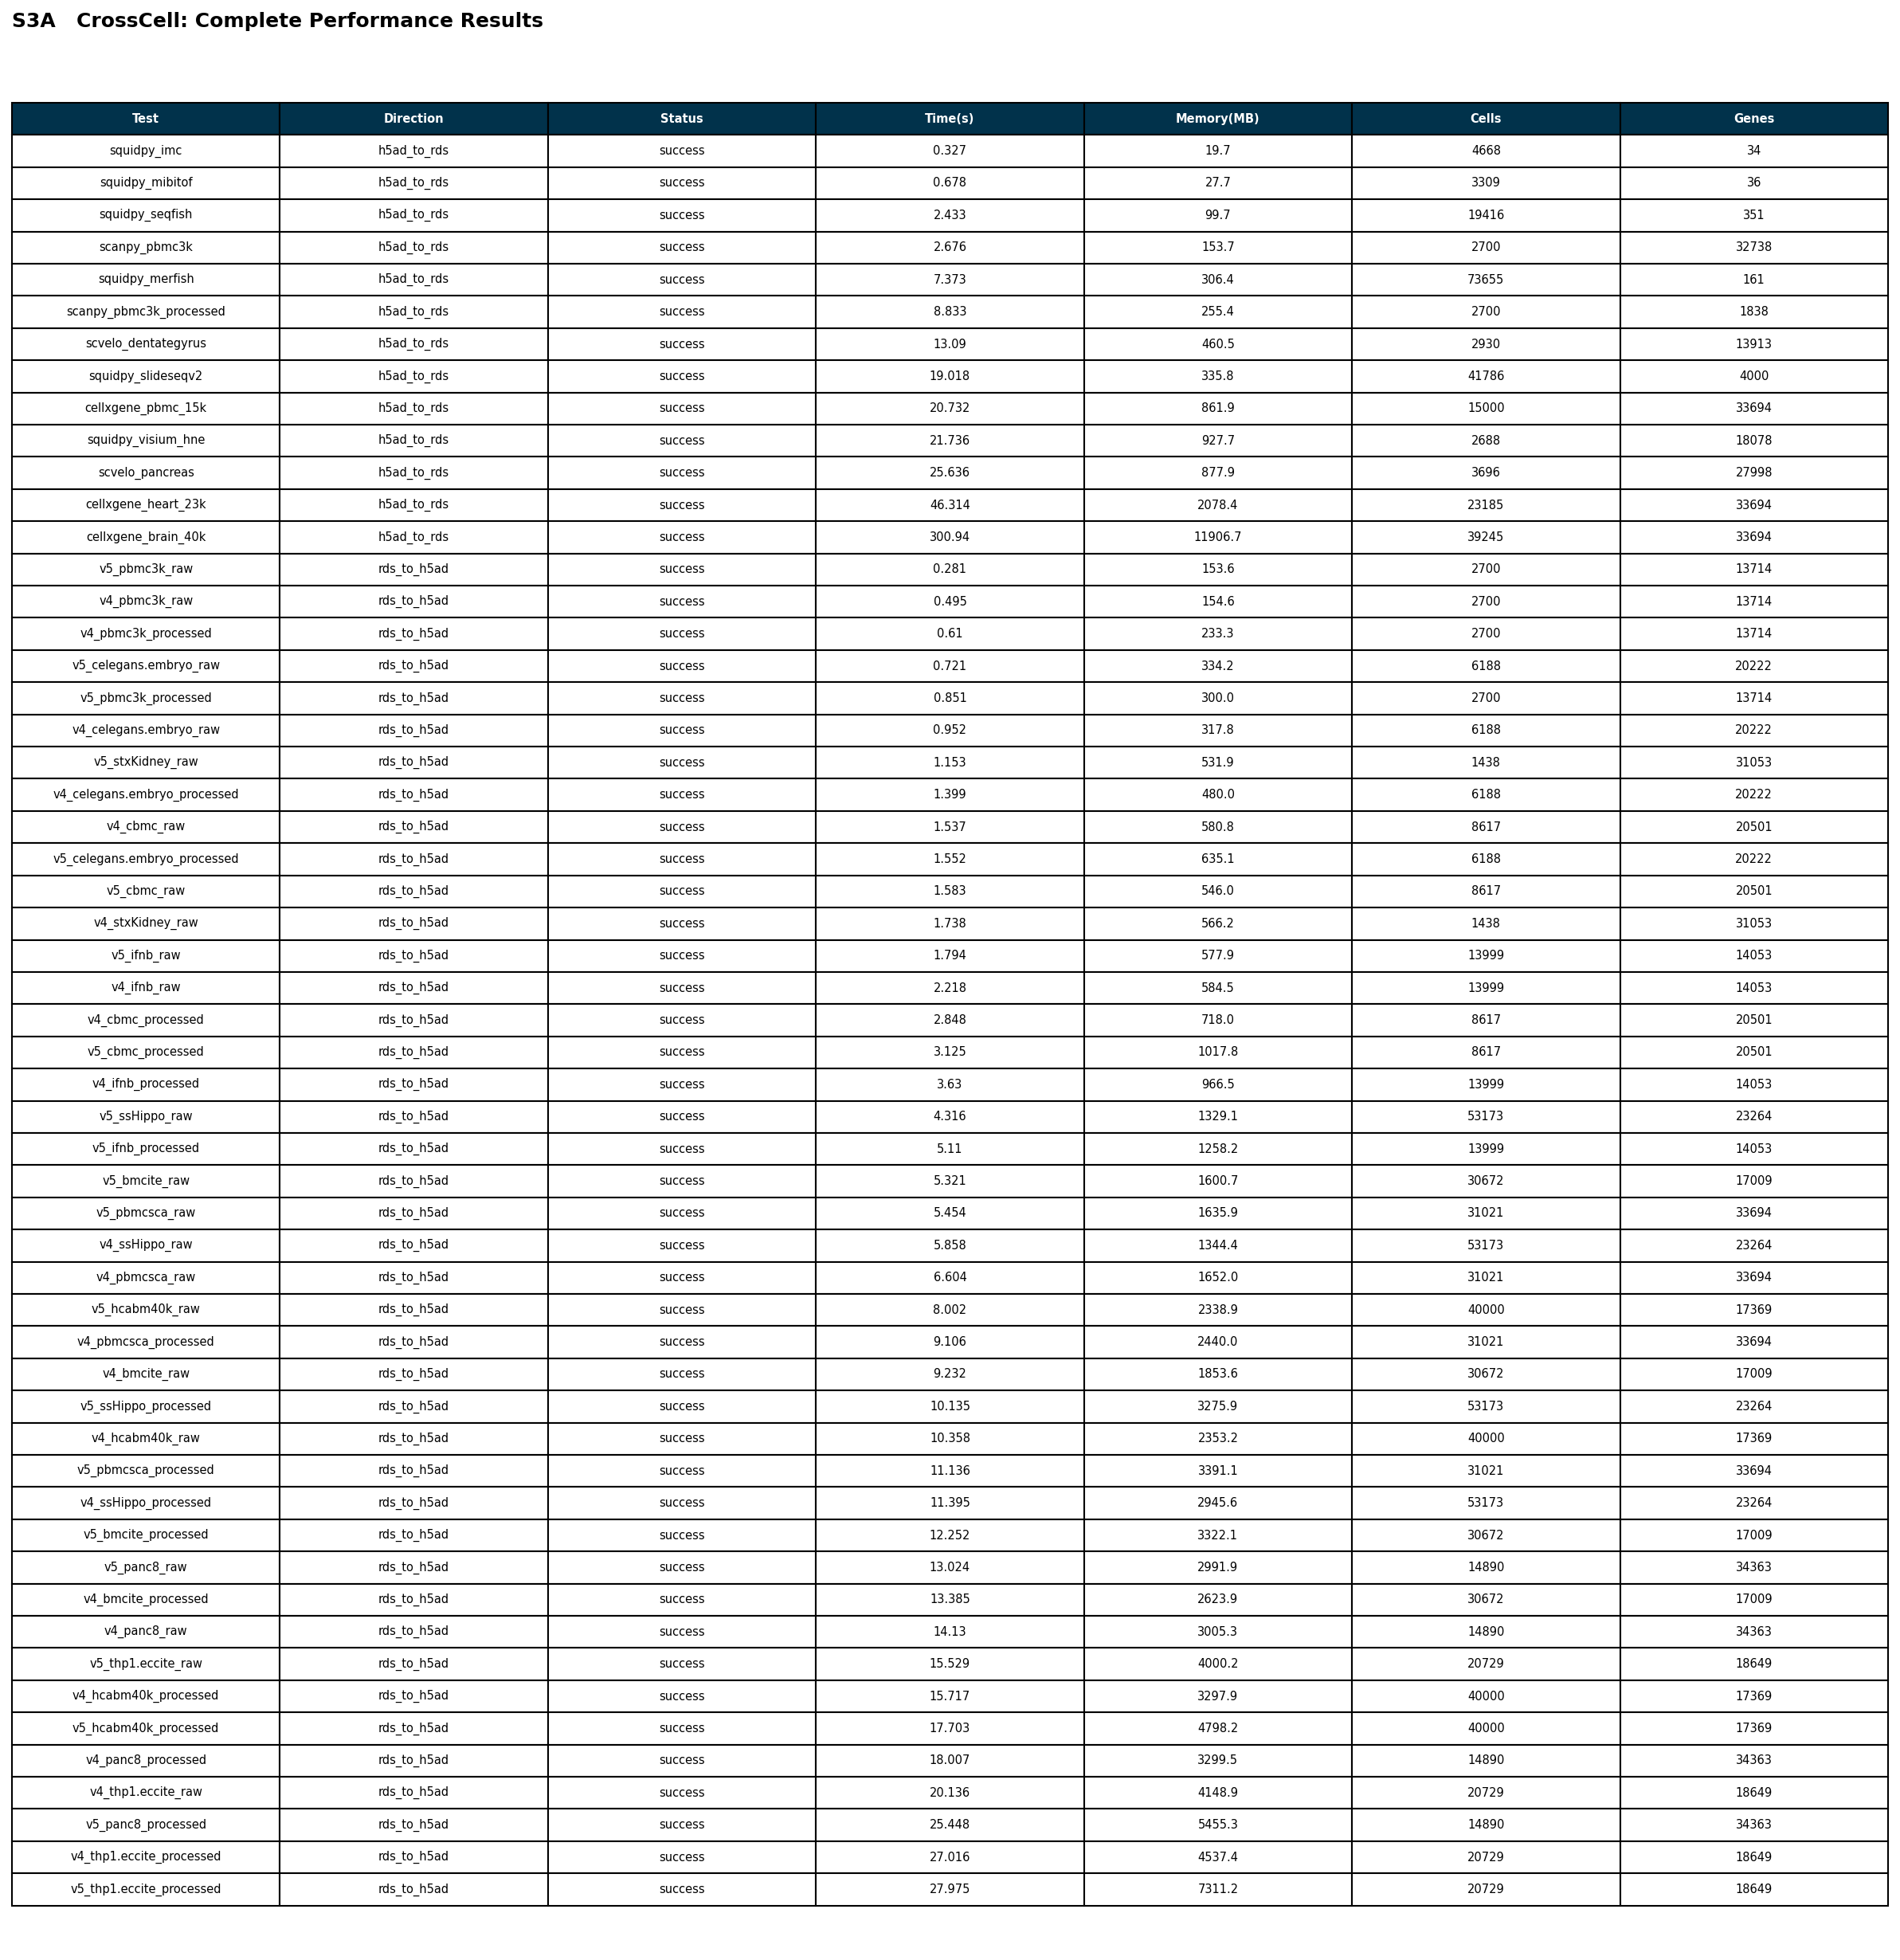

In [3]:

if len(df_cc) > 0:
    # Summary table
    summary = df_cc[['test_id', 'direction', 'status', 'conversion_time_seconds',
                      'peak_memory_mb', 'n_cells', 'n_genes']].copy()
    summary.columns = ['Test', 'Direction', 'Status', 'Time(s)', 'Memory(MB)', 'Cells', 'Genes']
    summary = summary.sort_values(['Direction', 'Time(s)'])

    fig, ax = plt.subplots(figsize=(16, max(8, len(summary)*0.3)))
    ax.axis('off')
    table = ax.table(cellText=summary.values, colLabels=summary.columns,
                     loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(7)
    table.scale(1, 1.3)
    for j in range(len(summary.columns)):
        table[0, j].set_facecolor('#01324b')
        table[0, j].set_text_props(color='white', fontweight='bold')
    ax.set_title('S3A   CrossCell: Complete Performance Results', fontweight='bold', loc='left', pad=20)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'supp1a_full_table.pdf')
    fig.savefig(FIGURES_DIR / 'supp1a_full_table.png')
    print('Saved supp3a')
    plt.show()
else:
    print('No CrossCell data available for table')


## 3. Supp Fig S1B: Per-Dataset Time Comparison

Saved supp3b


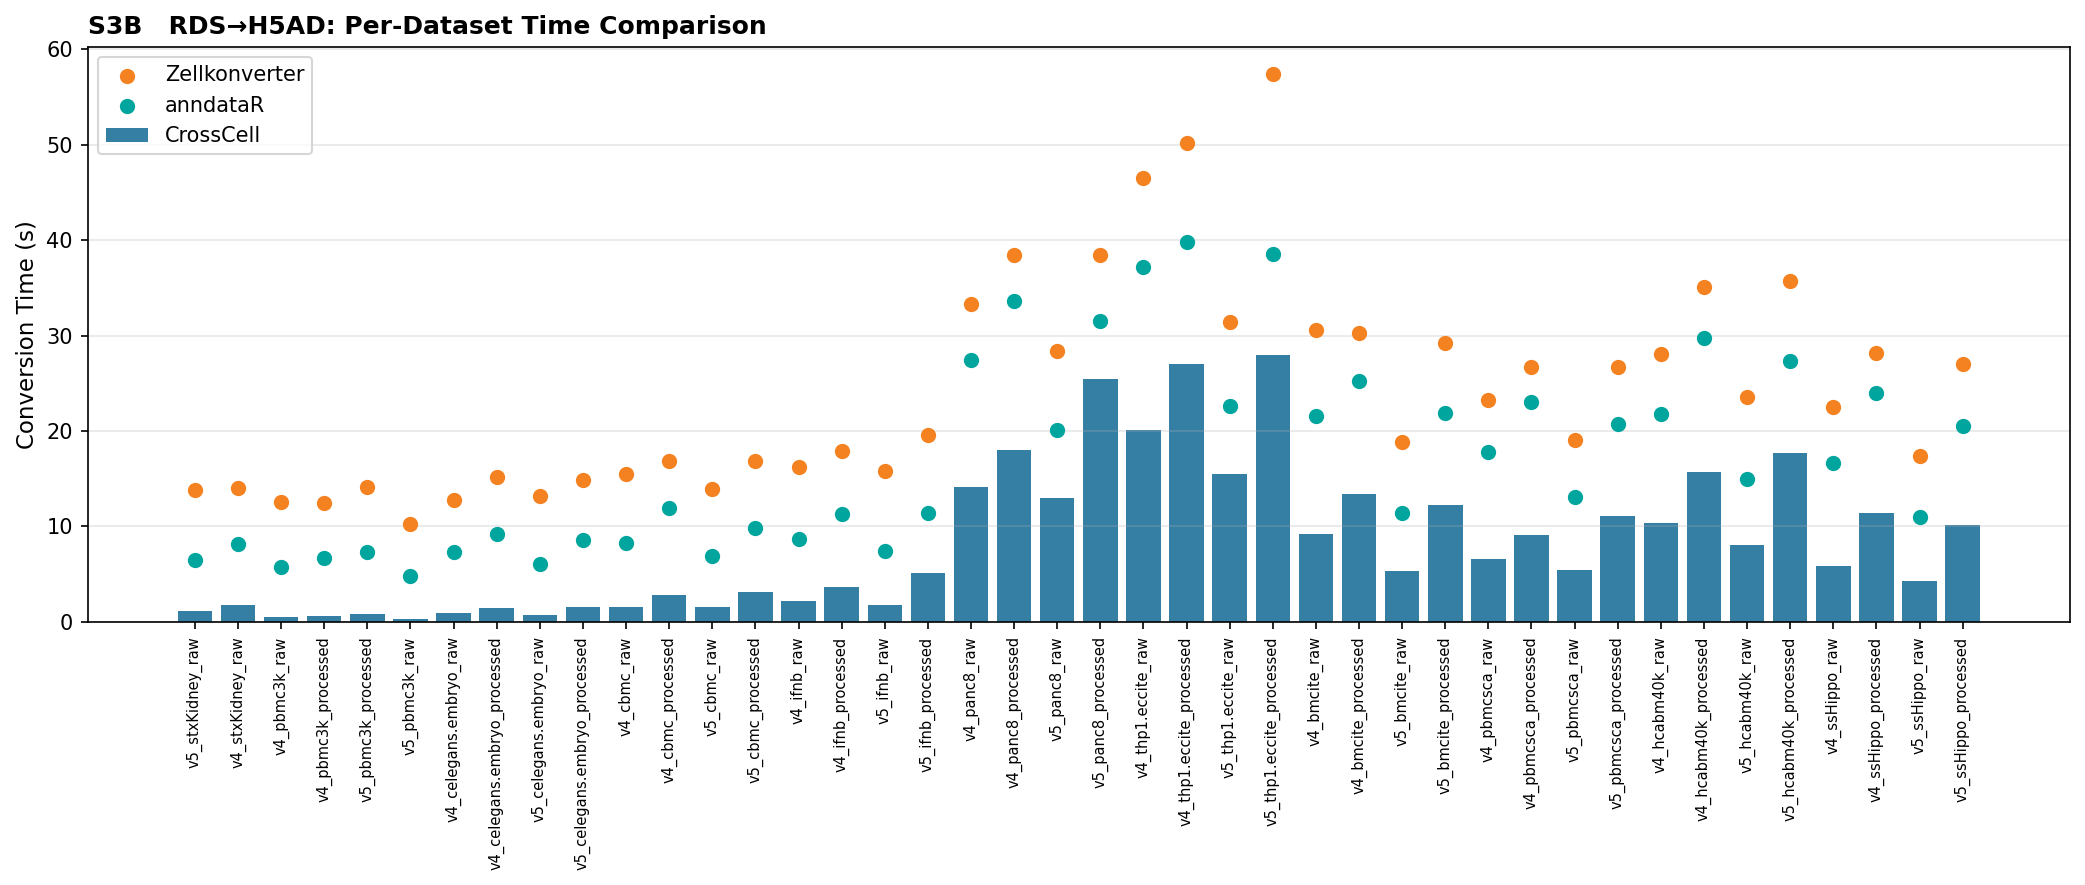

In [4]:

if len(df_cc) > 0:
    df_r2h = df_cc[df_cc['direction'] == 'rds_to_h5ad'].sort_values('n_cells')

    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(df_r2h))
    ax.bar(x, df_r2h['conversion_time_seconds'], color=COLORS['CrossCell'], alpha=0.8, label='CrossCell')

    # Overlay other tools if available
    for tool_key, tool_name in [('zellkonverter', 'Zellkonverter'), ('anndataR', 'anndataR')]:
        if tool_key in other_dfs:
            df_t = other_dfs[tool_key]
            df_t_r2h = df_t[df_t['direction'] == 'rds_to_h5ad']
            merged = df_r2h.merge(df_t_r2h[['test_id', 'conversion_time_seconds']],
                                  on='test_id', suffixes=('', f'_{tool_key}'), how='left')
            col = f'conversion_time_seconds_{tool_key}'
            if col in merged.columns:
                vals = merged[col].fillna(0).values
                ax.scatter(x, vals, s=40, color=COLORS.get(tool_name, '#999'),
                          marker='o', label=tool_name, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels(df_r2h['test_id'], rotation=90, fontsize=7)
    ax.set_ylabel('Conversion Time (s)')
    ax.set_title('S3B   RDS→H5AD: Per-Dataset Time Comparison', fontweight='bold', loc='left')
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'supp1b_time_comparison.pdf')
    fig.savefig(FIGURES_DIR / 'supp1b_time_comparison.png')
    print('Saved supp3b')
    plt.show()


## 4. Supp Fig S1C: Speedup Distribution by Category

Saved supp3c


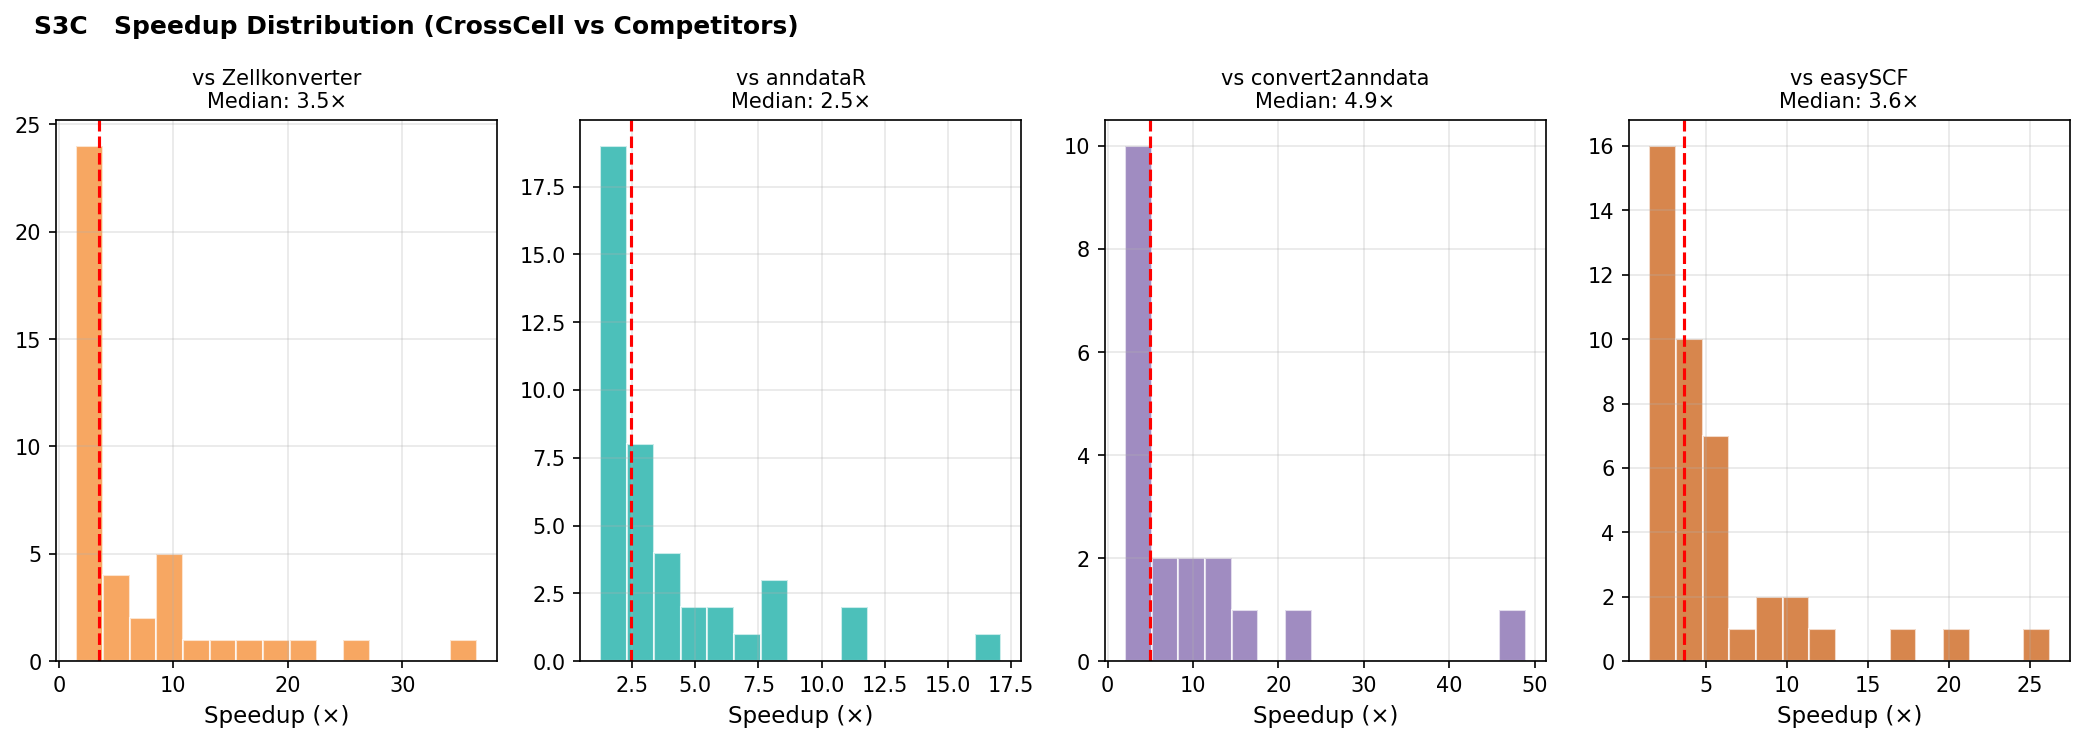

In [5]:

if len(df_cc) > 0 and len(other_dfs) > 0:
    fig, axes = plt.subplots(1, min(4, len(other_dfs)), figsize=(14, 5))
    if len(other_dfs) == 1: axes = [axes]

    for ax, (tool_key, df_t) in zip(axes, other_dfs.items()):
        tool_name = {'zellkonverter': 'Zellkonverter', 'anndataR': 'anndataR',
                     'convert2anndata': 'convert2anndata', 'easySCF': 'easySCF'}.get(tool_key, tool_key)
        df_t_r2h = df_t[(df_t['direction'] == 'rds_to_h5ad') & (df_t['status'] == 'success')]
        merged = df_cc[df_cc['direction'] == 'rds_to_h5ad'].merge(
            df_t_r2h[['test_id', 'conversion_time_seconds']], on='test_id',
            suffixes=('_cc', '_other'), how='inner')
        if len(merged) > 0:
            speedup = merged['conversion_time_seconds_other'] / merged['conversion_time_seconds_cc']
            ax.hist(speedup, bins=15, color=COLORS.get(tool_name, '#999'), alpha=0.7, edgecolor='white')
            ax.axvline(x=speedup.median(), color='red', linestyle='--', linewidth=1.5)
            ax.set_xlabel('Speedup (×)')
            ax.set_title(f'vs {tool_name}\nMedian: {speedup.median():.1f}×', fontsize=10)
        ax.grid(alpha=0.3)

    fig.suptitle('S3C   Speedup Distribution (CrossCell vs Competitors)', fontweight='bold', x=0.02, ha='left')
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'supp1c_speedup_dist.pdf')
    fig.savefig(FIGURES_DIR / 'supp1c_speedup_dist.png')
    print('Saved supp3c')
    plt.show()
else:
    print('Insufficient data for speedup analysis')


In [6]:

print('Supplementary Figure 1 complete.')
if len(df_cc) > 0:
    print(f'Total CrossCell tests: {len(df_cc)}')
    print(f'Success rate: {(df_cc["status"]=="success").sum()}/{len(df_cc)}')


Supplementary Figure 1 complete.
Total CrossCell tests: 55
Success rate: 55/55
